In [1]:
import os
import warnings
import boto3
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import ks_2samp

#### Functions

In [2]:
# compute evaluation metrics
def compute_metrics(arr_y_true, arr_y_pred):
    flt_auc = roc_auc_score(arr_y_true, arr_y_pred)
    flt_gini = 2 * flt_auc - 1
    flt_ks = ks_2samp(arr_y_pred[arr_y_true == 1], arr_y_pred[arr_y_true == 0]).statistic
    flt_pr_auc = average_precision_score(arr_y_true, arr_y_pred)
    flt_brier = brier_score_loss(arr_y_true, arr_y_pred)
    flt_median_pred = np.median(arr_y_pred)
    flt_mean_pred = np.mean(arr_y_pred)
    flt_target_mean = np.mean(arr_y_true)
    return {'flt_auc': flt_auc, 'flt_gini': flt_gini, 'flt_ks': flt_ks, 'flt_pr_auc': flt_pr_auc, 'flt_brier': flt_brier, 'flt_median_pred': flt_median_pred, 'flt_mean_pred': flt_mean_pred, 'flt_target_mean': flt_target_mean}

In [3]:
# plot roc curves
def plot_roc_curves(dict_splits, str_filename='output/roc_curves.png'):
    fig, ax = plt.subplots(figsize=(8, 6))
    list_colors = ['steelblue', 'salmon', 'seagreen']
    for (str_name, (arr_y_true, arr_y_pred)), str_color in zip(dict_splits.items(), list_colors):
        flt_auc = roc_auc_score(arr_y_true, arr_y_pred)
        arr_fpr, arr_tpr, _ = roc_curve(arr_y_true, arr_y_pred)
        ax.plot(arr_fpr, arr_tpr, color=str_color, linewidth=2, label=f'{str_name} (AUC={flt_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title('ROC Curves', fontsize=16)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [4]:
# plot precision recall curves
def plot_precision_recall_curves(dict_splits, str_filename='output/precision_recall_curves.png'):
    fig, ax = plt.subplots(figsize=(8, 6))
    list_colors = ['steelblue', 'salmon', 'seagreen']
    for (str_name, (arr_y_true, arr_y_pred)), str_color in zip(dict_splits.items(), list_colors):
        flt_pr_auc = average_precision_score(arr_y_true, arr_y_pred)
        arr_precision, arr_recall, _ = precision_recall_curve(arr_y_true, arr_y_pred)
        ax.plot(arr_recall, arr_precision, color=str_color, linewidth=2, label=f'{str_name} (PR AUC={flt_pr_auc:.4f})')
    ax.set_title('Precision-Recall Curves', fontsize=16)
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [5]:
# plot calibration
def plot_calibration(dict_splits, int_n_bins=10, str_filename='output/calibration.png'):
    fig, ax = plt.subplots(figsize=(8, 6))
    list_colors = ['steelblue', 'salmon', 'seagreen']
    for (str_name, (arr_y_true, arr_y_pred)), str_color in zip(dict_splits.items(), list_colors):
        flt_brier = brier_score_loss(arr_y_true, arr_y_pred)
        arr_bins = np.linspace(0, 1, int_n_bins + 1)
        arr_bin_indices = np.digitize(arr_y_pred, arr_bins) - 1
        arr_bin_indices = np.clip(arr_bin_indices, 0, int_n_bins - 1)
        list_predicted = []
        list_actual = []
        for i in range(int_n_bins):
            arr_mask = arr_bin_indices == i
            if arr_mask.sum() > 0:
                list_predicted.append(arr_y_pred[arr_mask].mean())
                list_actual.append(arr_y_true[arr_mask].mean())
        ax.plot(list_predicted, list_actual, marker='o', color=str_color, linewidth=2, label=f'{str_name} (Brier={flt_brier:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title('Calibration Plot', fontsize=16)
    ax.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax.set_ylabel('Actual Default Rate', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [6]:
# plot kde of predictions
def plot_kde_predictions(dict_splits, str_filename='output/kde_predictions.png'):
    warnings.filterwarnings('ignore')
    fig, ax = plt.subplots(figsize=(10, 5))
    list_colors = ['steelblue', 'salmon', 'seagreen']
    for (str_name, (arr_y_true, arr_y_pred)), str_color in zip(dict_splits.items(), list_colors):
        flt_median = np.median(arr_y_pred)
        sns.kdeplot(arr_y_pred, ax=ax, color=str_color, linewidth=2, label=f'{str_name} (Median={flt_median:.4f})', fill=True, alpha=0.2)
    ax.set_title('KDE of Predictions', fontsize=16)
    ax.set_xlabel('Predicted Probability', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    warnings.filterwarnings('default')

In [7]:
# plot confusion matrix
def plot_confusion_matrix(arr_y_true, arr_y_pred, flt_threshold=0.5, str_filename='output/confusion_matrix.png'):
    arr_y_class = (arr_y_pred >= flt_threshold).astype(int)
    arr_cm = confusion_matrix(arr_y_true, arr_y_class)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(arr_cm, display_labels=['No Default', 'Default']).plot(ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix (Threshold={flt_threshold})', fontsize=16)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [8]:
# plot shap partial dependence plots
def plot_shap_pdp(model, arr_X, list_feature_cols, str_filename='output/shap_pdp.png'):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(arr_X)
    int_n_features = len(list_feature_cols)
    int_n_cols = 3
    int_n_rows = int(np.ceil(int_n_features / int_n_cols))
    fig, axes = plt.subplots(int_n_rows, int_n_cols, figsize=(6 * int_n_cols, 4 * int_n_rows))
    axes = axes.flatten()
    for i, str_col in enumerate(list_feature_cols):
        ax = axes[i]
        ax.scatter(arr_X[:, i], shap_values[:, i], alpha=0.3, s=5, color='steelblue')
        ax.set_title(str_col, fontsize=12)
        ax.set_xlabel('Feature Value', fontsize=10)
        ax.set_ylabel('SHAP Value', fontsize=10)
        ax.axhline(y=0, color='black', linewidth=0.5)
    # hide unused axes
    for j in range(int_n_features, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('SHAP Partial Dependence Plots', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300, bbox_inches='tight')
    plt.show()

In [9]:
# plot decile analysis
def plot_decile_analysis(arr_y_true, arr_y_pred, str_filename='output/decile_analysis.png'):
    warnings.filterwarnings('ignore')
    # create dataframe for binning
    df_decile = pd.DataFrame({'y_true': arr_y_true, 'y_pred': arr_y_pred})
    df_decile['decile'] = pd.qcut(df_decile['y_pred'], 10, labels=False, duplicates='drop')
    # compute stats per decile
    list_rows = []
    for int_d in sorted(df_decile['decile'].unique()):
        df_sub = df_decile[df_decile['decile'] == int_d]
        flt_min_pred = df_sub['y_pred'].min()
        flt_max_pred = df_sub['y_pred'].max()
        int_count = len(df_sub)
        flt_actual_rate = df_sub['y_true'].mean()
        list_rows.append({
            'int_decile': int_d + 1,
            'str_pd_range': f'{flt_min_pred:.3f}-{flt_max_pred:.3f}',
            'int_count': int_count,
            'flt_actual_default_rate': flt_actual_rate,
        })
    df_stats = pd.DataFrame(list_rows)
    # cumulative capture rate (proportion of all defaults captured from highest decile down)
    int_total_defaults = int(arr_y_true.sum())
    df_decile_sorted = df_decile.sort_values('y_pred', ascending=False)
    df_decile_sorted['cum_defaults'] = df_decile_sorted['y_true'].cumsum()
    # assign capture rate per decile (descending)
    list_capture = []
    for int_d in sorted(df_decile['decile'].unique()):
        # count defaults in deciles >= current (i.e., higher risk deciles)
        int_captured = int(df_decile[df_decile['decile'] >= int_d]['y_true'].sum())
        flt_capture = int_captured / int_total_defaults if int_total_defaults > 0 else 0.0
        list_capture.append(flt_capture)
    # reverse to match ascending decile order (decile 10 = highest risk)
    df_stats['flt_cumulative_capture_rate'] = list_capture
    # display table
    print(df_stats.to_string(index=False))
    # plot
    fig, ax = plt.subplots(figsize=(10, 6))
    arr_x = np.arange(len(df_stats))
    ax.bar(arr_x, df_stats['flt_actual_default_rate'], color='steelblue', edgecolor='black')
    # annotate bars
    for i, flt_rate in enumerate(df_stats['flt_actual_default_rate']):
        ax.text(i, flt_rate + 0.005, f'{flt_rate:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(arr_x)
    ax.set_xticklabels(df_stats['str_pd_range'], rotation=45, ha='right', fontsize=8)
    ax.set_title('Actual Default Rate by Predicted PD Decile', fontsize=16)
    ax.set_xlabel('Predicted PD Range (Decile)', fontsize=12)
    ax.set_ylabel('Actual Default Rate', fontsize=12)
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    warnings.filterwarnings('default')

In [10]:
# plot threshold sensitivity analysis
def plot_threshold_analysis(arr_y_true, arr_y_pred, str_filename='output/threshold_analysis.png'):
    from sklearn.metrics import precision_score, recall_score, f1_score
    list_thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.50]
    list_rows = []
    for flt_thresh in list_thresholds:
        arr_y_class = (arr_y_pred >= flt_thresh).astype(int)
        flt_precision = precision_score(arr_y_true, arr_y_class, zero_division=0)
        flt_recall = recall_score(arr_y_true, arr_y_class, zero_division=0)
        flt_f1 = f1_score(arr_y_true, arr_y_class, zero_division=0)
        flt_approval_rate = (arr_y_pred < flt_thresh).mean()
        list_rows.append({
            'flt_threshold': flt_thresh,
            'flt_precision': flt_precision,
            'flt_recall': flt_recall,
            'flt_f1': flt_f1,
            'flt_approval_rate': flt_approval_rate,
        })
    df_thresh = pd.DataFrame(list_rows)
    # display table
    print(df_thresh.to_string(index=False))
    # plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(df_thresh['flt_threshold'], df_thresh['flt_precision'], marker='o', color='steelblue', linewidth=2, label='Precision')
    ax.plot(df_thresh['flt_threshold'], df_thresh['flt_recall'], marker='s', color='salmon', linewidth=2, label='Recall')
    ax.plot(df_thresh['flt_threshold'], df_thresh['flt_f1'], marker='^', color='seagreen', linewidth=2, label='F1')
    ax.plot(df_thresh['flt_threshold'], df_thresh['flt_approval_rate'], marker='D', color='gray', linewidth=2, linestyle='--', label='Approval Rate')
    ax.set_title('Threshold Sensitivity Analysis', fontsize=16)
    ax.set_xlabel('Threshold', fontsize=12)
    ax.set_ylabel('Score / Rate', fontsize=12)
    ax.legend(loc='lower right')
    ax.set_xticks(list_thresholds)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

#### Constants

In [11]:
# bucket
str_bucket = os.getcwd().split('/')[4].replace('_', '-')
print(f'Bucket: {str_bucket}')

# step
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')

# s3 input path
str_s3_input = f's3://{str_bucket}/03_preprocessing'
print(f'S3 Input: {str_s3_input}')

# target
str_target = 'default_12m'
print(f'Target: {str_target}')

# model and feature columns
str_model_path = '../04_model/output/xgboost_model.joblib'
str_feature_cols_path = '../04_model/output/feature_cols.joblib'

# output directory
os.makedirs('output', exist_ok=True)

Bucket: credit-risk-claude
Step: 05_model_eval
S3 Input: s3://credit-risk-claude/03_preprocessing
Target: default_12m


#### Read Data and Model

In [12]:
# read preprocessed data
df_train = pd.read_parquet(f'{str_s3_input}/df_train_clean.parquet')
df_valid = pd.read_parquet(f'{str_s3_input}/df_valid_clean.parquet')
df_test = pd.read_parquet(f'{str_s3_input}/df_test_clean.parquet')

# combine train and valid (model was trained on combined train+valid)
df_train_valid = pd.concat([df_train, df_valid], ignore_index=True)

# load model and feature columns
model = joblib.load(str_model_path)
list_feature_cols = joblib.load(str_feature_cols_path)

print(f'Train+Valid: {df_train_valid.shape}')
print(f'Test: {df_test.shape}')
print(f'Features: {len(list_feature_cols)}')

Train+Valid: (21511, 20)
Test: (3797, 20)
Features: 12


/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


#### Generate Predictions

In [13]:
# generate predictions
arr_y_train_valid = df_train_valid[str_target].values
arr_y_test = df_test[str_target].values

arr_pred_train_valid = model.predict_proba(df_train_valid[list_feature_cols].values)[:, 1]
arr_pred_test = model.predict_proba(df_test[list_feature_cols].values)[:, 1]

# dict for passing to plot functions
dict_splits = {
    'Train+Valid': (arr_y_train_valid, arr_pred_train_valid),
    'Test': (arr_y_test, arr_pred_test),
}

#### Metrics Summary

AUC, Gini (2*AUC-1), and KS statistic for Train+Valid (in-sample) and Test (out-of-time holdout). The model was trained on combined train+valid data, so Train+Valid metrics reflect in-sample performance while Test is the true out-of-time evaluation. Gini is the standard discrimination metric in credit risk. KS measures the maximum separation between the cumulative distributions of defaulters and non-defaulters.

In [14]:
# compute metrics for each split
list_rows = []
for str_name, (arr_y_true, arr_y_pred) in dict_splits.items():
    dict_metrics = compute_metrics(arr_y_true, arr_y_pred)
    dict_metrics['str_split'] = str_name
    list_rows.append(dict_metrics)

df_metrics = pd.DataFrame(list_rows)[['str_split', 'flt_auc', 'flt_gini', 'flt_ks', 'flt_pr_auc', 'flt_brier', 'flt_median_pred', 'flt_mean_pred', 'flt_target_mean']]
df_metrics.to_csv('output/metrics_summary.csv', index=False)
df_metrics

,str_split,flt_auc,flt_gini,flt_ks,flt_pr_auc,flt_brier,flt_median_pred,flt_mean_pred,flt_target_mean
0,Train+Valid,0.811380,0.622761,0.462922,0.527394,0.118889,0.130756,0.187438,0.187578
1,Test,0.802437,0.604874,0.469198,0.480909,0.119920,0.132741,0.186126,0.182513


#### ROC Curves

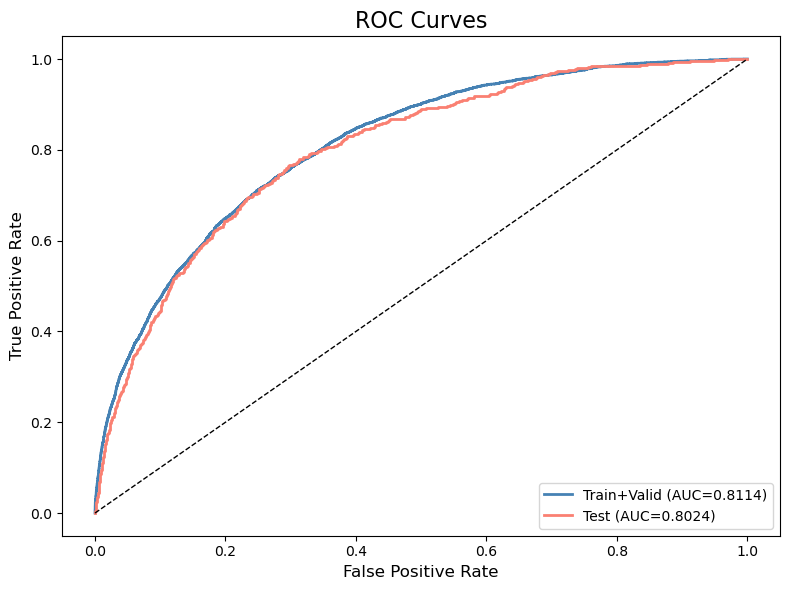

In [15]:
plot_roc_curves(dict_splits)

#### Precision-Recall Curves

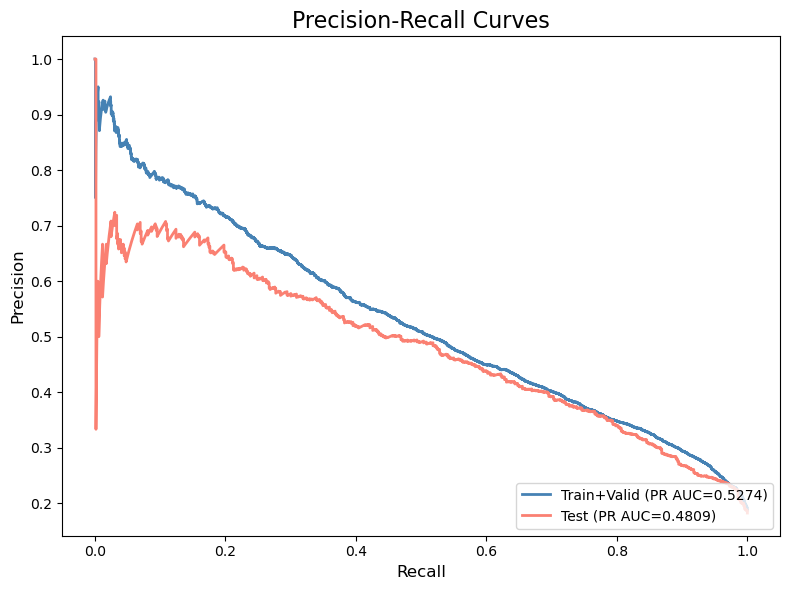

In [16]:
plot_precision_recall_curves(dict_splits)

#### Calibration

Calibration measures how well the predicted probabilities match actual default rates. A well-calibrated model's points will fall close to the diagonal. This is critical for credit risk because predicted probabilities are used directly for pricing and capital allocation.

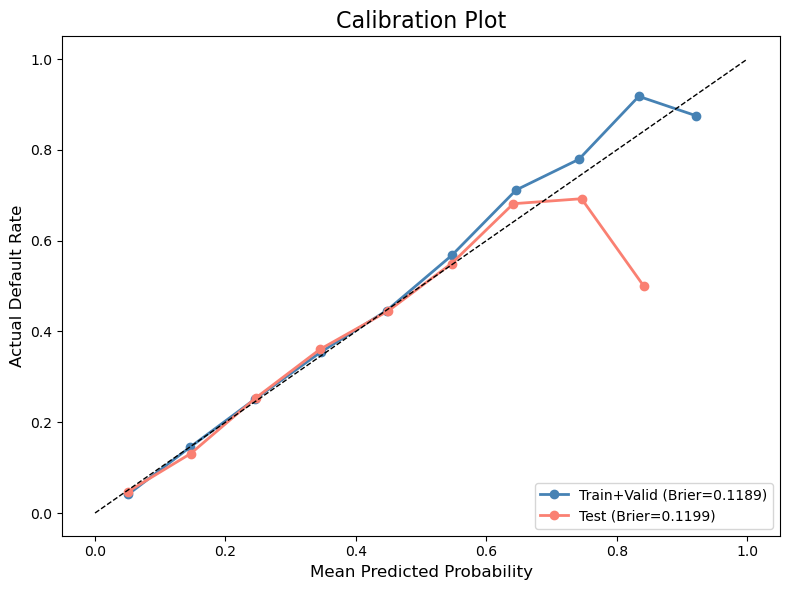

In [17]:
plot_calibration(dict_splits)

#### KDE of Predictions

KDE plots show the distribution of predicted probabilities across splits. Similar distributions indicate stable model behavior. Divergence between Train+Valid and Test may indicate overfitting or data drift.

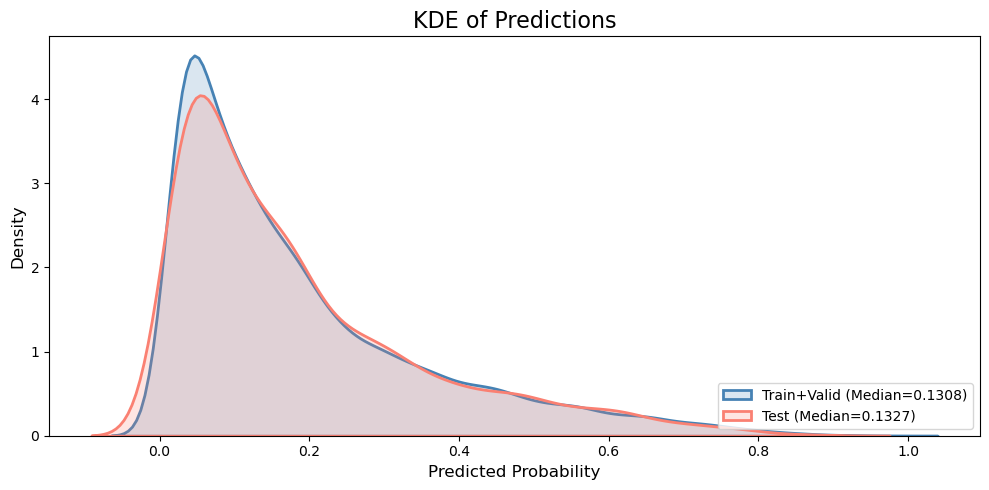

In [18]:
plot_kde_predictions(dict_splits)

#### Confusion Matrix (Test Set)

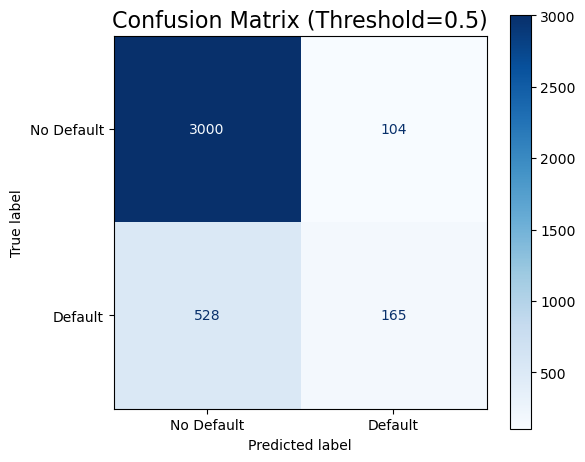

In [19]:
plot_confusion_matrix(arr_y_test, arr_pred_test)

#### SHAP Partial Dependence Plots

SHAP partial dependence plots show the relationship between each feature's value and its SHAP contribution to the prediction. These are useful for verifying that monotone constraints are being respected and for understanding the nonlinear relationships the model has learned.

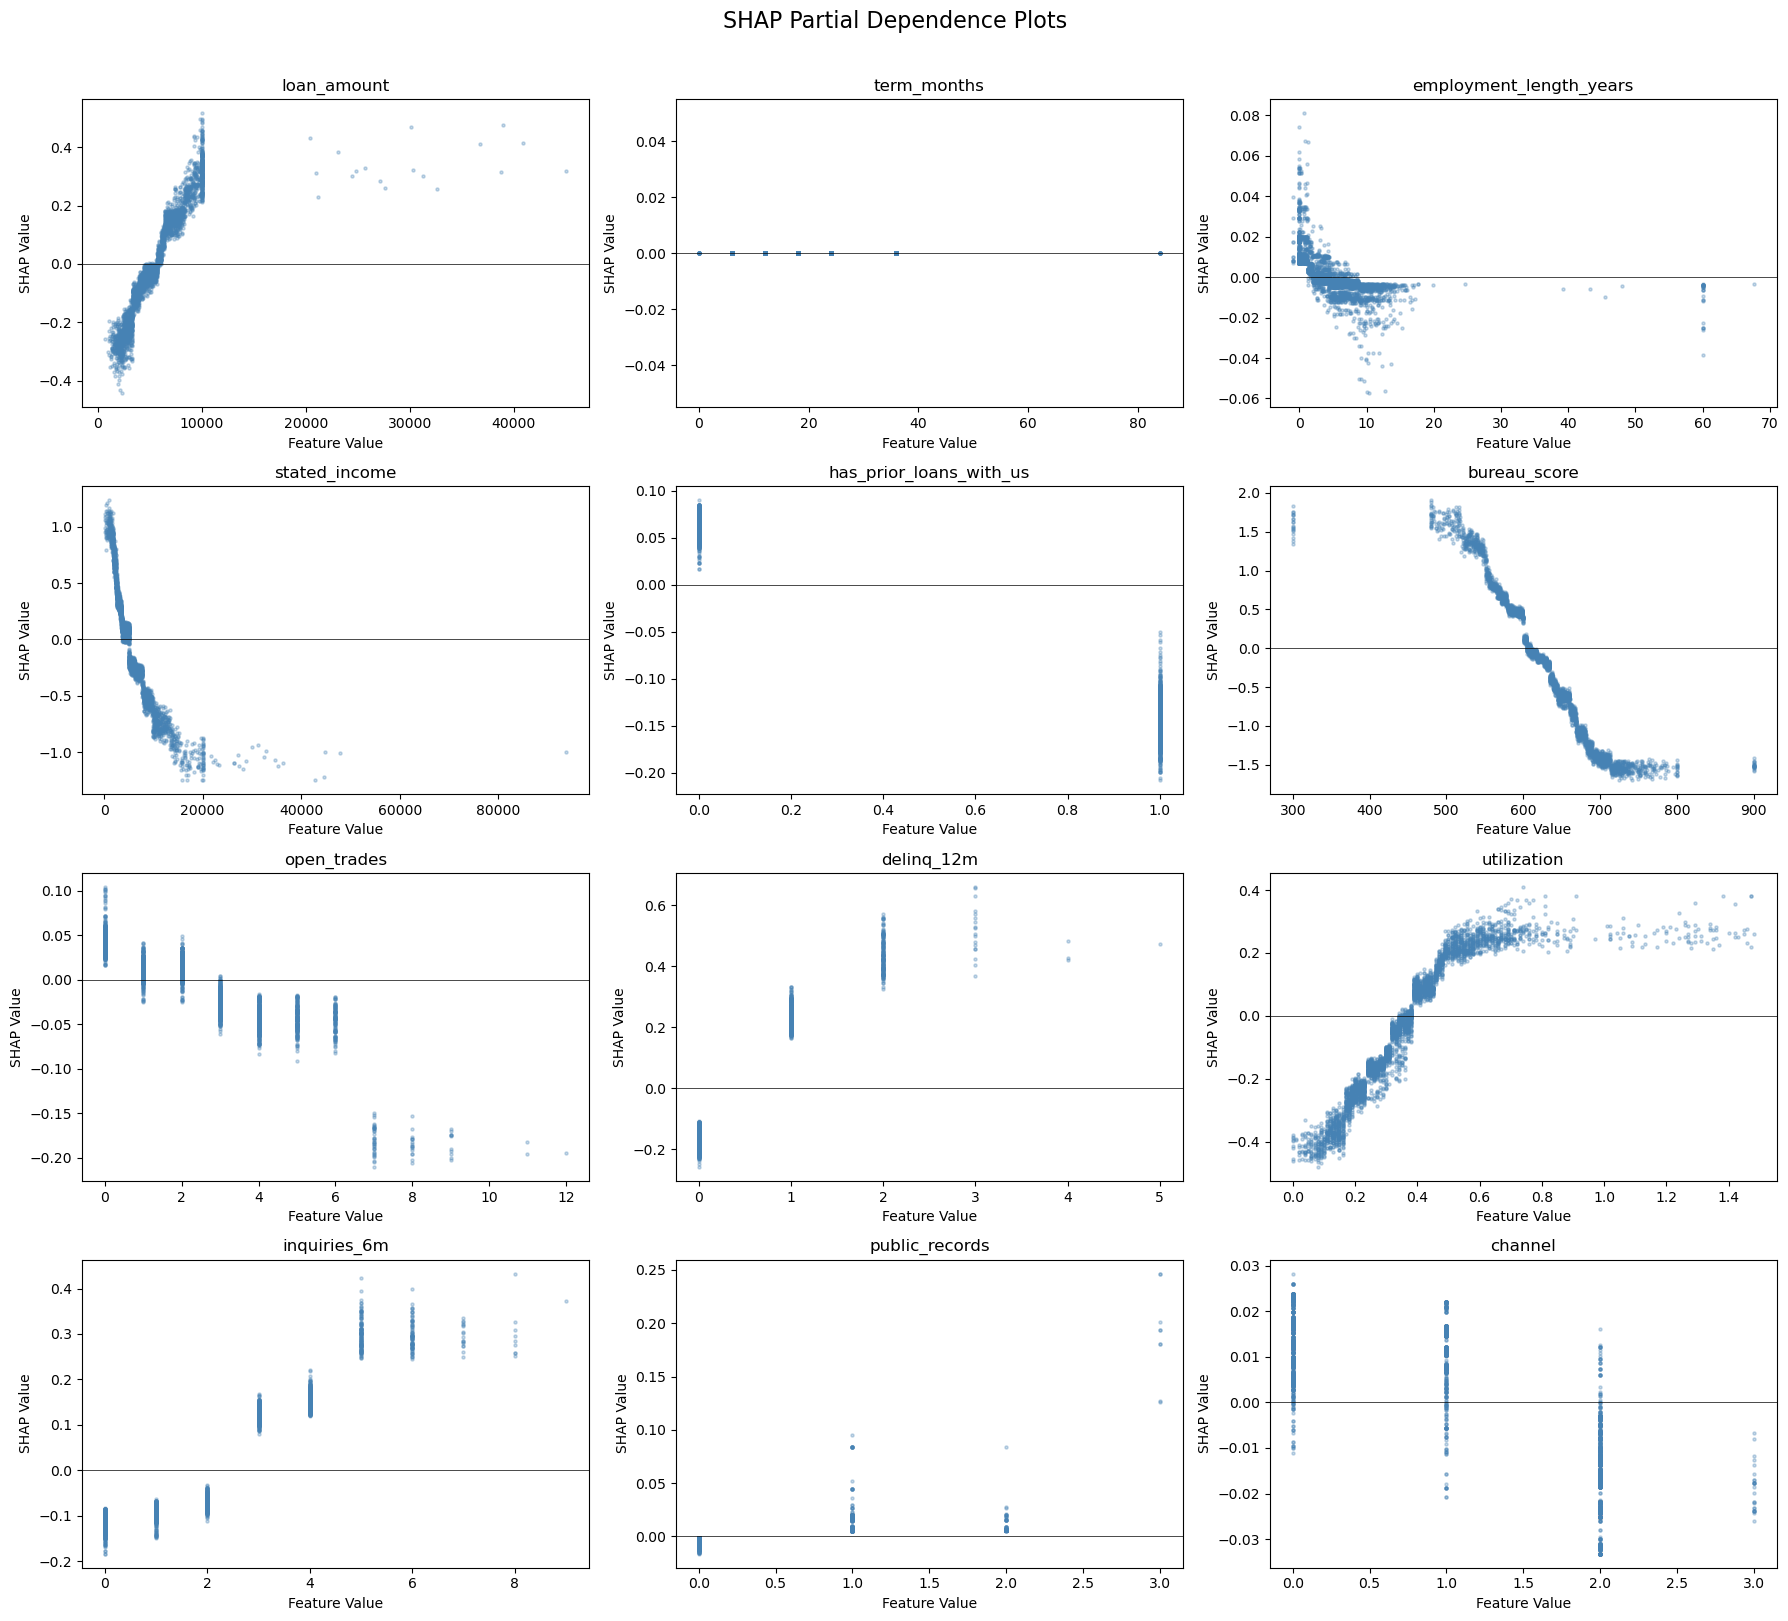

In [20]:
plot_shap_pdp(model, df_test[list_feature_cols].values, list_feature_cols)

#### Decile Analysis

Decile analysis is standard in credit risk for evaluating rank-ordering within score bands. Predictions are binned into 10 equal-sized groups, and the actual default rate is compared across deciles. A well-discriminating model will show monotonically increasing default rates from the lowest to the highest decile.

 int_decile str_pd_range  int_count  flt_actual_default_rate  flt_cumulative_capture_rate
          1  0.006-0.029        380                 0.015789                     1.000000
          2  0.029-0.047        380                 0.015789                     0.991342
          3  0.047-0.071        379                 0.068602                     0.982684
          4  0.071-0.098        380                 0.092105                     0.945166
          5  0.098-0.133        380                 0.086842                     0.894661
          6  0.133-0.171        379                 0.121372                     0.847042
          7  0.171-0.222        380                 0.207895                     0.780664
          8  0.222-0.304        379                 0.258575                     0.666667
          9  0.304-0.444        380                 0.384211                     0.525253
         10  0.446-0.878        380                 0.573684                     0.314574


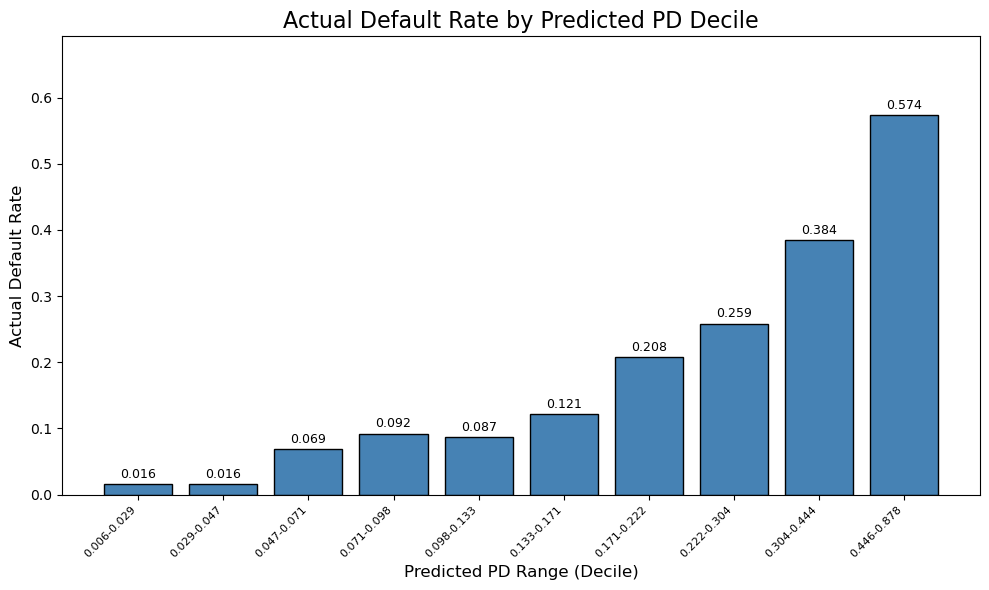

In [21]:
plot_decile_analysis(arr_y_test, arr_pred_test)

#### Threshold Sensitivity Analysis

The optimal classification cutoff depends on the cost of false positives versus false negatives and varies by business use case. A lower threshold catches more defaults (higher recall) but declines more applicants (lower approval rate). This analysis shows precision, recall, F1, and approval rate across a range of thresholds to support business decision-making.

 flt_threshold  flt_precision  flt_recall   flt_f1  flt_approval_rate
          0.10       0.274823    0.894661 0.420482           0.405847
          0.15       0.326225    0.816739 0.466227           0.543060
          0.20       0.386006    0.708514 0.499746           0.664999
          0.25       0.431000    0.621934 0.509155           0.736634
          0.30       0.469833    0.528139 0.497283           0.794838
          0.50       0.613383    0.238095 0.343035           0.929155


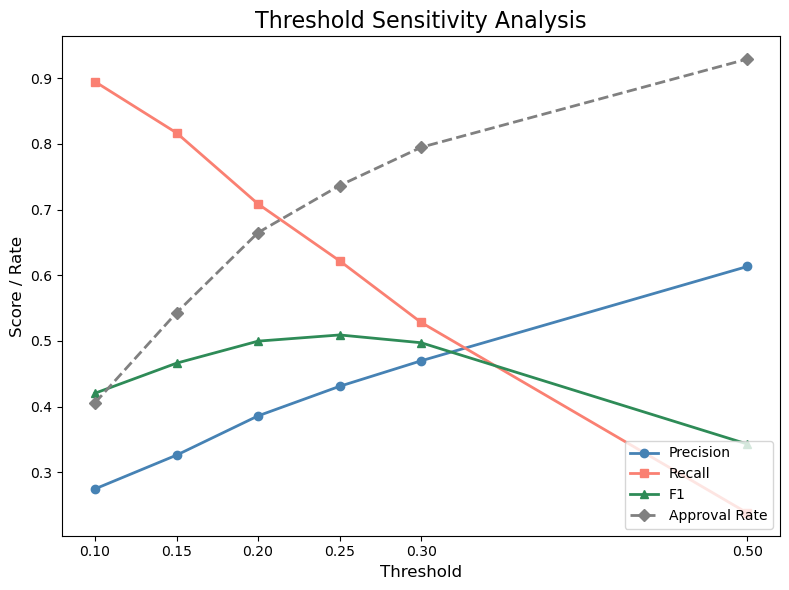

In [22]:
plot_threshold_analysis(arr_y_test, arr_pred_test)